# Quantum Gates Homework

## PLEASE READ ALL SECTIONS

## Overview
In this tutorial, you will learn to build quantum circuits using Qiskit.

Qiskit is an open-source Python library primarily written in Rust. With its huge community, Qiskit has excellent performance and learning resources. You can learn more about Qiskit on [IBM Quantum Learning][1].

<img alt="Image" src="https://quantum.cloud.ibm.com/learning/images/courses/fundamentals-of-quantum-algorithms/hero.svg" width=90%>

## Objectives
* Learn how to use the [Qiskit API][2]
* Understand how to create and manipulate statevectors
* Apply matrix and tensor math to design quantum gates
* Build quantum circuits

## Grading
You are expected to write your own code. It is acceptable to find and use code from the [Qiskit API][2] and [IBM Quantum Learning][1] webpages, but **it is strictly prohibited to use code obtained from other sources**, especially other students. You are also expected to write descriptive comments explaining what your code is trying to accomplish and why.

**DO NOT MODIFY PRE-EXISTING CODE! ONLY WRITE CODE WHERE SPECIFIED!**

**NOT FOLLOWING INSTRUCTIONS MAKES GRADING MORE DIFFICULT FOR THE GRADERS AND MAY WARRANT LOSS OF CREDIT!**

There are a total of 150 points in this homework.

**Applies to Undergraduate Students Only:** 
You are graded out of 100 points meaning you only need 100 points to earn a 100% grade. You can earn more than 100 points for extra credit. There are 50 extra points each worth 0.2% of the notebook grade. Earning all 150 points yields a 110% grade. Given this assignment is worth 10% of your course grade, you can expect 1% extra course grade credit if you earn all 150 points.

**Applies to Graduate Students Only:**
You are graded out of 150 points. There is no extra credit for this assignment.

These are the following gradable items and their weights
1. Statevectors (36 pts)
    1. Creating Statevectors from Dirac BraKet Notation (12 pts)
    2. Evolving Statevectors with Quantum Gates (12 pts)
    3. Multi-Qubit Statevectors (12 pts)
        
2. Building Gates (64 pts)
    1. Arbitrary Unitary Gates (20 pts)
    2. Gate Composition (24 pts)
    3. Gates from Quantum Circuits (20 pts)
        
3. The Swap Test (50 pts)
    1. Building a Swap Gate (10 pts)
    2. Building the Swap Test Circuit (10 pts)
    3. Turning the Swap Test into a Gate (5 pts)
    4. Swap Test Experiments (25 pts)
        

[1]: https://learning.quantum.ibm.com/
[2]: https://docs.quantum.ibm.com/api/qiskit
[3]: https://www.ibm.com/quantum/images/qiskit/qiskit-leadspace-SM.svg

### Environment Verification
Before you proceed, please verify your kernel is running the **Python 3.12** environment you created with `pip install -r requirements.txt`<br><br>
If you don't see your environment in the kernel list, you need to add it using the terminal and relaunch jupyter. You can add your environment to interactive python using this command<br><br> `ipython kernel install --user --name=ENV_NAME` (replacing `ENV_NAME`)<br><br>
After you've selected the correct environment, run this next cell, but do NOT edit it in any way! If no errors pop up, then your environment should be able to run this notebook with ease.

In [2]:
# DO NOT EDIT THIS CELL
n = 20

import sys
print("python", sys.version)

import numpy
print("numpy".ljust(n), numpy.__version__)

import qiskit
print("qiskit".ljust(n), qiskit.__version__)

python 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
numpy                2.4.2
qiskit               2.2.2


### Library Imports
We will need these libraries, classes, and utilities to write and run code for this homework. There should be no import errors if everything is installed correctly.

In [4]:
# General
import numpy as np

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import IGate, SXGate, XGate, YGate, ZGate, SGate, TGate, TdgGate, \
                                HGate, UnitaryGate, RYGate, CXGate, CZGate, SwapGate
from qiskit.visualization import plot_bloch_multivector, plot_state_city


# **Section 1: Statevectors (36 pts)**
This section is dedicated to working with statevectors using Qiskit. Statevectors are essentially the math structure storing quantum information.

## **Part 1: Creating Statevectors from Dirac BraKet Notation (12 pts)**
Using Qiskit's [`Statevector`](https://docs.quantum.ibm.com/api/qiskit/qiskit.quantum_info.Statevector) class, You will be constructing the statevectors for the single-qubit quantum states $|0\rangle$, $|1\rangle$, $|+\rangle$, $|i\rangle$. You must verify your statevector appear correct using [`plot_bloch_multivector`](https://docs.quantum.ibm.com/api/qiskit/qiskit.visualization.plot_bloch_multivector#qiskitvisualizationplot_bloch_multivector).

### $|0\rangle$ Statevector (3 pts)
Create the `Statevector` for $|0\rangle$ and plot it. 

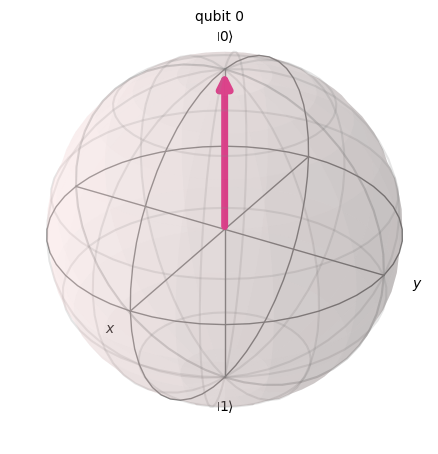

In [5]:
# Create circuit with a single qubit (default state of |0>)
circuit = QuantumCircuit(1)
# Convert it to a statevector
state = Statevector(circuit)
# Plot statevector
plot_bloch_multivector(state)


### $|1\rangle$ Statevector (3 pts)
Create the `Statevector` for $|1\rangle$ and plot it.

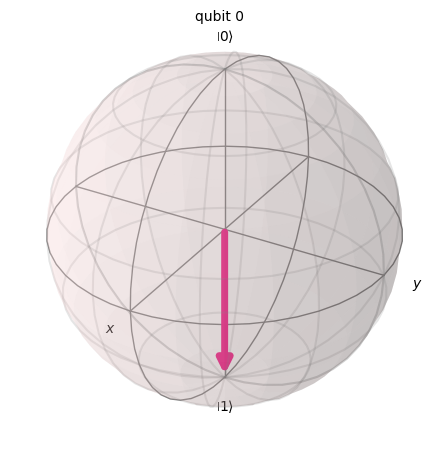

In [32]:
# Create circuit with a single qubit (default state of |0>)
circuit = QuantumCircuit(1)
# Apply X gate to qubit to flip it to |1>
circuit.x(0)
# Convert it to a statevector
state = Statevector(circuit)
# Plot statevector
plot_bloch_multivector(state)


### $|+\rangle$ Statevector (3 pts)
Create the `Statevector` for $|+\rangle$ and plot it.

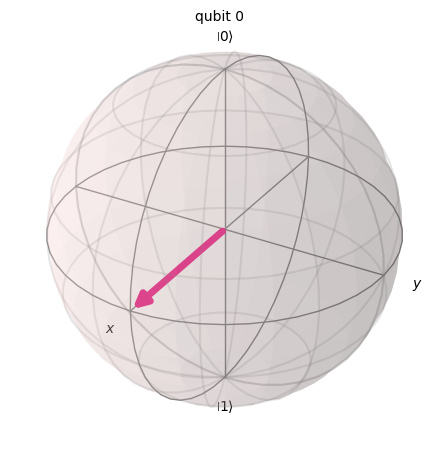

In [ ]:
# Create circuit with a single qubit (default state of |0>)
circuit = QuantumCircuit(1)
# Apply hadamard gate to qubit to flip it to |+>
circuit.h(0)
# Convert it to a statevector
state = Statevector(circuit)
# Plot statevector
plot_bloch_multivector(state)

### $|i\rangle$ Statevector (3 pts)
Create the `Statevector` for $|i\rangle$ and plot it.

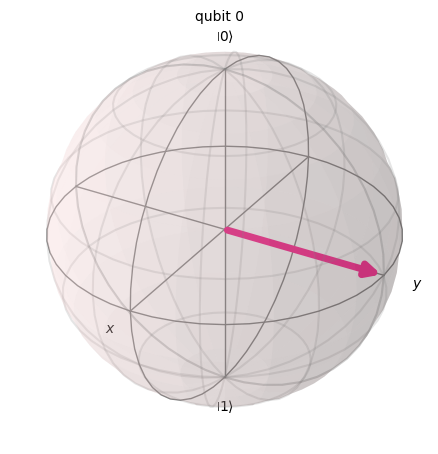

In [6]:
# Create circuit with a single qubit (default state of |0>)
circuit = QuantumCircuit(1)
# Apply RX gate by 3pi/2 to qubit to flip it to |i>
circuit.rx(3*(np.pi/2), 0)
# Convert it to a statevector
state = Statevector(circuit)
# Plot statevector
plot_bloch_multivector(state)


## **Part 2: Evolving Statevectors with Quantum Gates (12 pts)**
Given statevector `sv_initial`, You will be using its `evolve` method to apply a variety of gates from Qiskit's [Standard Gates](https://docs.quantum.ibm.com/api/qiskit/circuit_library#standard-gates) library and plot the results with `plot_bloch_multivector`.

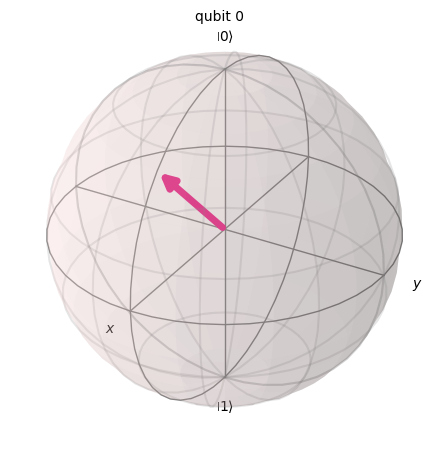

In [5]:
sv_initial = Statevector(np.array([np.sin(3*np.pi/8), np.cos(3*np.pi/8)]))
plot_bloch_multivector(sv_initial)

## Evolve using XGate (3 pts)
Apply an `XGate` to the statevector `sv_initial` using its `evolve` method and plot the result with `plot_bloch_multivector`.

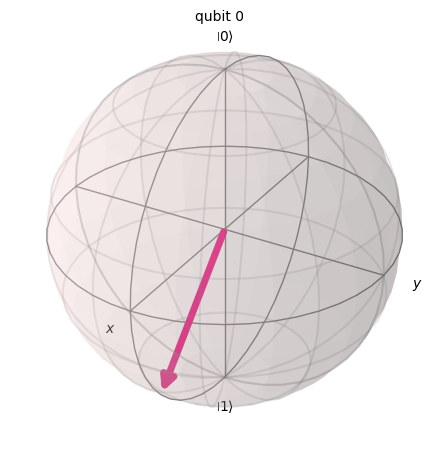

In [ ]:
# Evolve sv_initial over an XGate
new_sv = sv_initial.evolve(XGate())
plot_bloch_multivector(new_sv)

## Evolve using HGate (3 pts)
Apply an `HGate` to the statevector `sv_initial` using its `evolve` method and plot the result with `plot_bloch_multivector`.

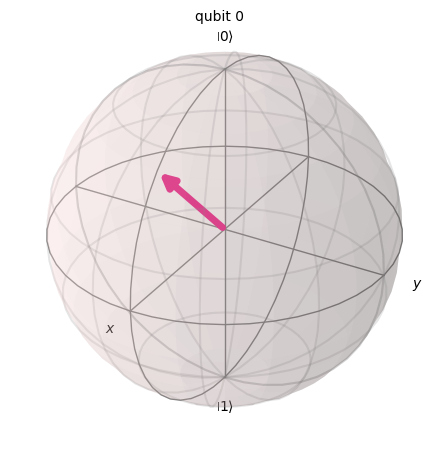

In [8]:
# Evolve sv_initial over an HGate
new_sv = sv_initial.evolve(HGate())
plot_bloch_multivector(new_sv)

## Evolve using ZGate (3 pts)
Apply a `ZGate` to the statevector `sv_initial` using its `evolve` method and plot the result with `plot_bloch_multivector`.

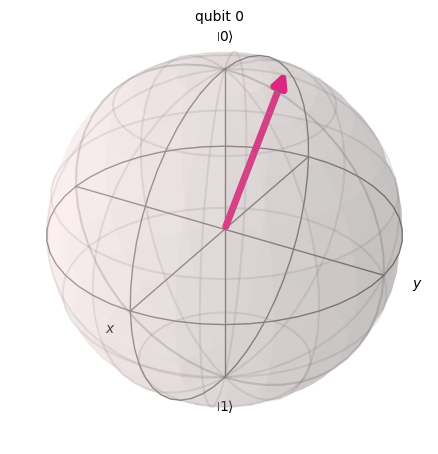

In [9]:
# Evolve sv_initial over an ZGate
new_sv = sv_initial.evolve(ZGate())
plot_bloch_multivector(new_sv)

## Evolve using RYGate (3 pts)
Apply an `RYGate` with an angle of $\frac{3\pi}{4}$ to the statevector `sv_initial` using its `evolve` method and plot the result with `plot_bloch_multivector`.

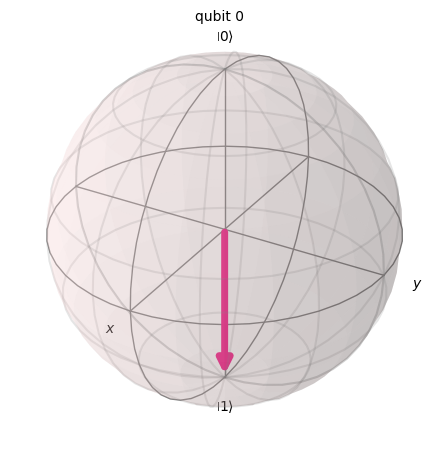

In [11]:
# Evolve sv_initial over an RYGate of 3pi/4
new_sv = sv_initial.evolve(RYGate(3*np.pi/4))
plot_bloch_multivector(new_sv)


## **Part 3: Multi-Qubit Statevectors (12 pts)**
Now that we understand how to construct single-qubit statevectors and apply single-qubit gates to them, we will work with multi-qubit statevectors.

## Creating Entangled States (8 pts)
There are 4 maximally entangled 2-qubit quantum states known as "Bell states". These are known as $|\Phi^+\rangle$, $|\Phi^-\rangle$, $|\Psi^+\rangle$, and $|\Psi^-\rangle$. You can find more info on them on [Wikipedia](https://en.wikipedia.org/wiki/Bell_state#Bell_basis). You will be creating a `Statevector` for each one and plotting it using [`plot_state_city`](https://docs.quantum.ibm.com/api/qiskit/qiskit.visualization.plot_state_city#qiskitvisualizationplot_state_city)

### $|\Phi^+\rangle$ Statevector (2 pts)
Create the `Statevector` for $|\Phi^+\rangle$ and plot it. 

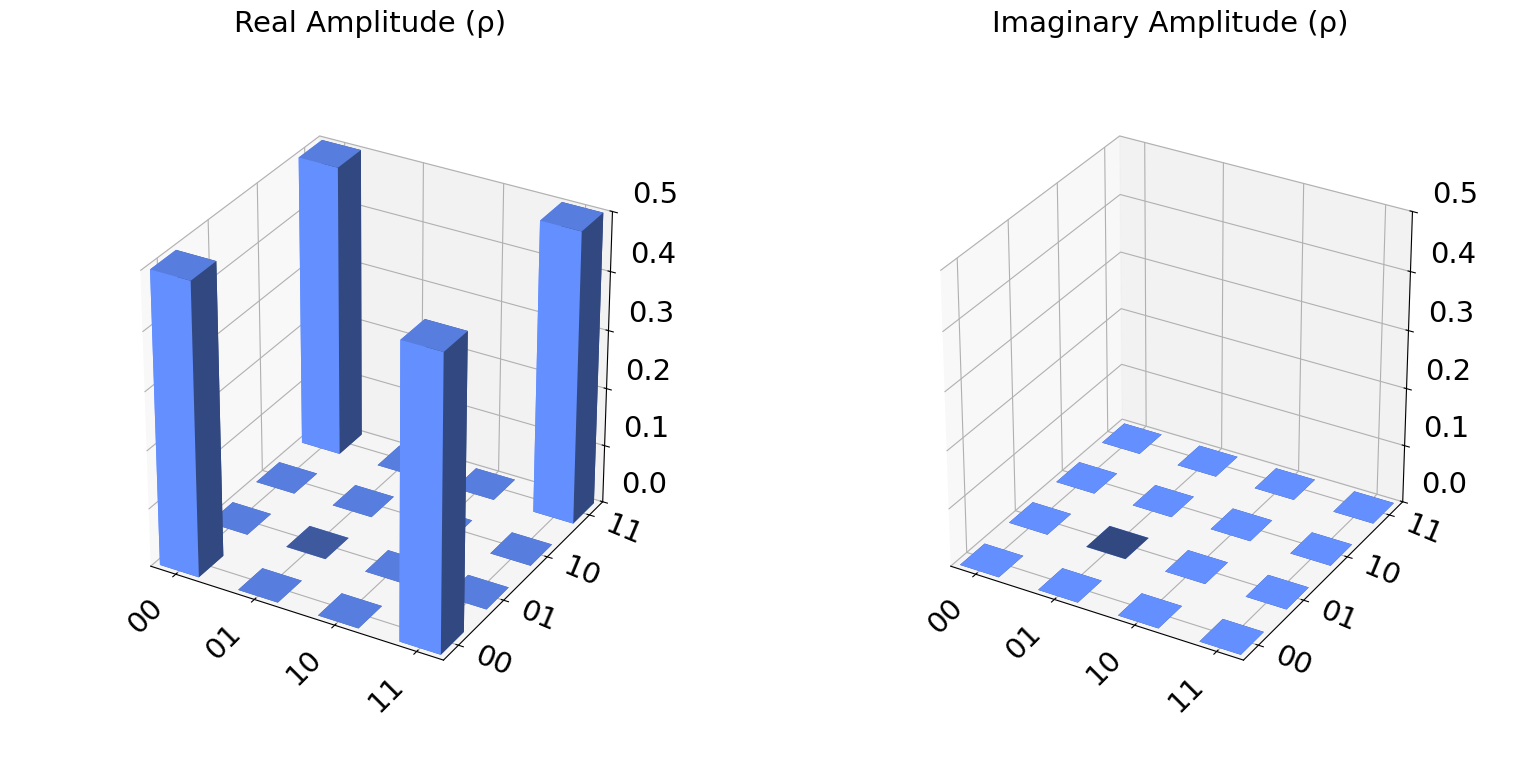

In [ ]:
# Create two-qubit circuit
circuit = QuantumCircuit(2)
# Apply a hadamard gate, then c-not gate to bit 0 of the circuit 
circuit.h(0)
circuit.cx(0, 1)
# Convert to statevector and plot
phi_plus = Statevector(circuit)
plot_state_city(phi_plus)

### $|\Phi^-\rangle$ Statevector (2 pts)
Create the `Statevector` for $|\Phi^-\rangle$ and plot it. 

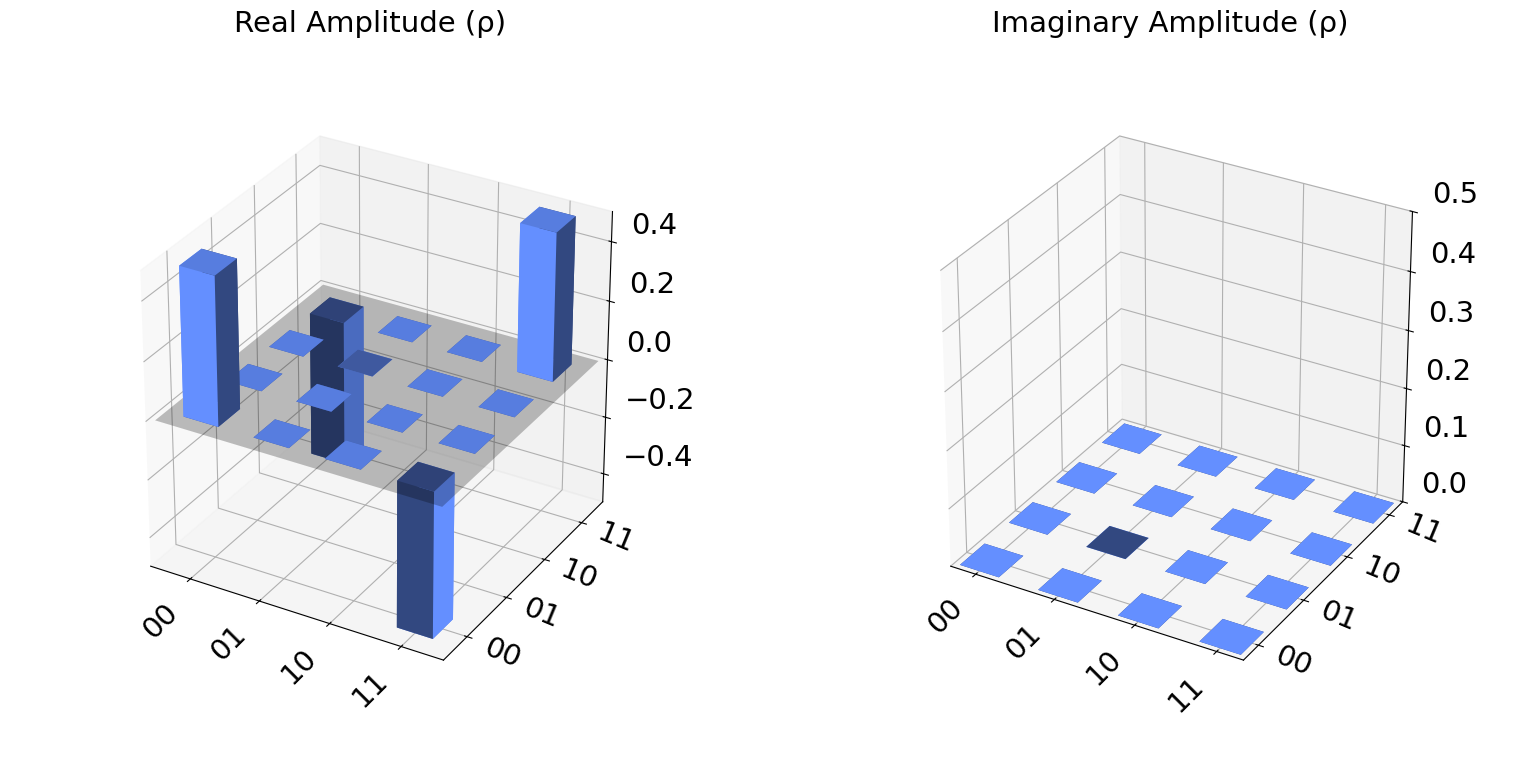

In [21]:
# Create two-qubit circuit
circuit = QuantumCircuit(2)
# Apply a hadamard gate, then c-not gate to the circuit 
circuit.h(0)
circuit.cx(0, 1)
# Apply a Z gate to flip the phase
circuit.z(0)
# Convert to statevector and plot
phi_minus = Statevector(circuit)
plot_state_city(phi_minus)

### $|\Psi^+\rangle$ Statevector (2 pts)
Create the `Statevector` for $|\Psi^+\rangle$ and plot it. 

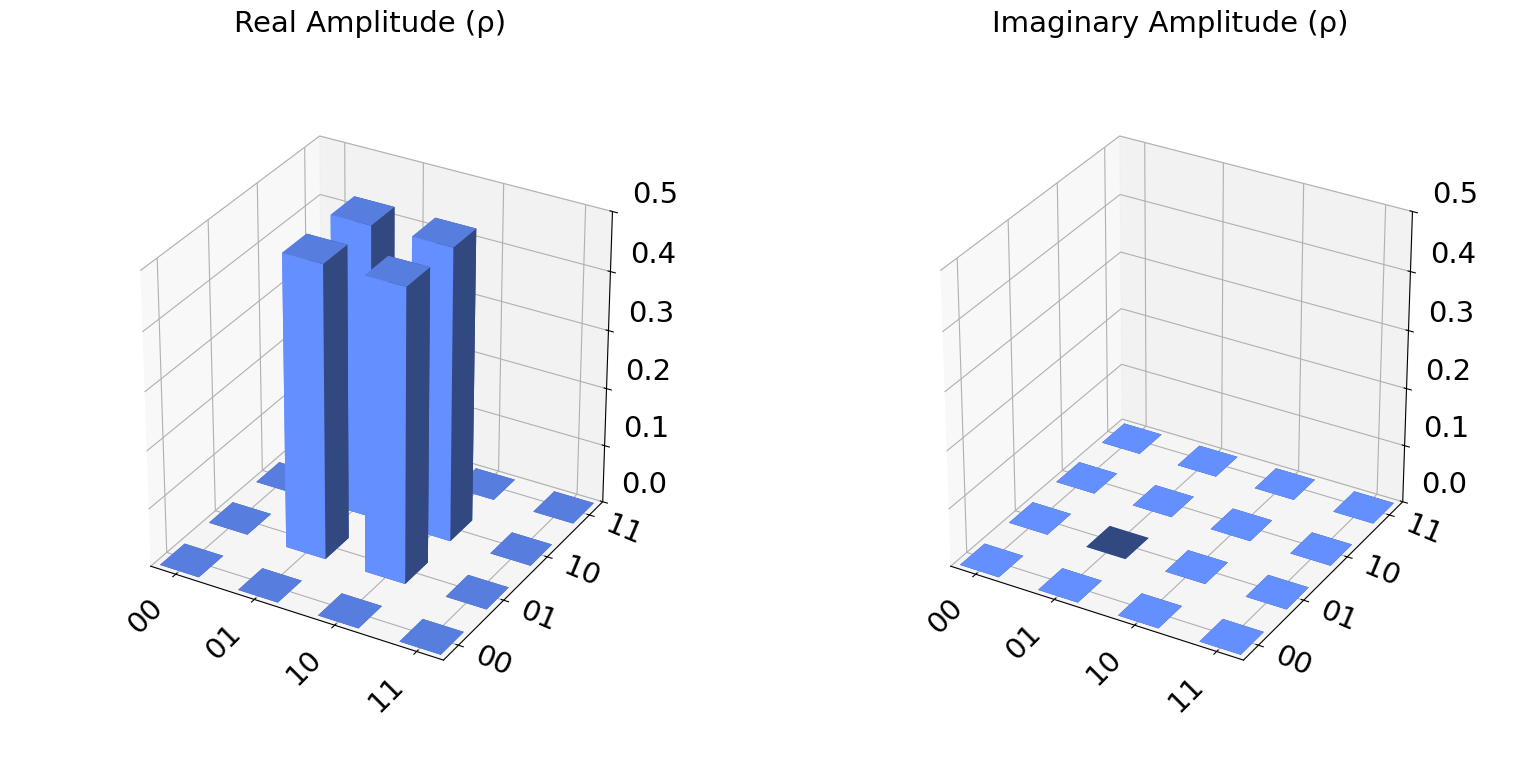

In [ ]:
# Create two-qubit circuit
circuit = QuantumCircuit(2)
# Apply an X gate to bit 0, then ahadamard gate to bit 1
circuit.x(0)
circuit.h(1)
# Apply a c-not gate to bit 1 
circuit.cx(1, 0)
# Convert to statevector and plot
psi_plus = Statevector(circuit)
plot_state_city(psi_plus)


### $|\Psi^-\rangle$ Statevector (2 pts)
Create the `Statevector` for $|\Psi^-\rangle$ and plot it. 

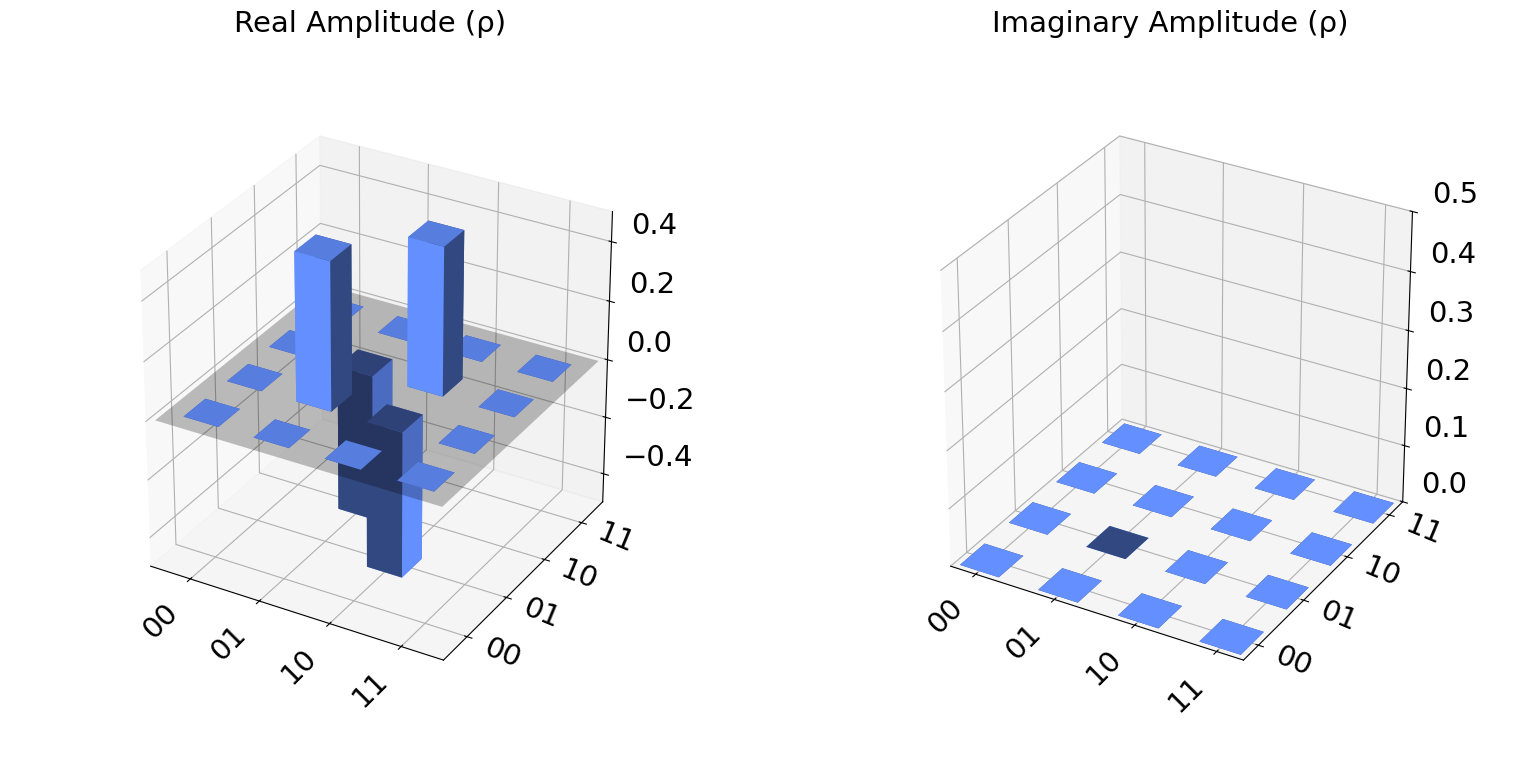

In [31]:
# Create two-qubit circuit
circuit = QuantumCircuit(2)
# Apply an X Gate to bit 0, then ahadamard gate to bit 1
circuit.x(0)
circuit.h(1)
# Apply a c-not gate to bit 1 
circuit.cx(1, 0)
# Apply a Z gate to flip the phase
circuit.z(1)
# Convert to statevector and plot
psi_minus = Statevector(circuit)
plot_state_city(psi_minus)

### Operations with Multi-Qubit Statevectors (4 pts)
Find and use a 2-qubit gate on the statevector $|\Phi^-\rangle$ to transform it to the statevector $|\Phi^+\rangle$ and plot it.

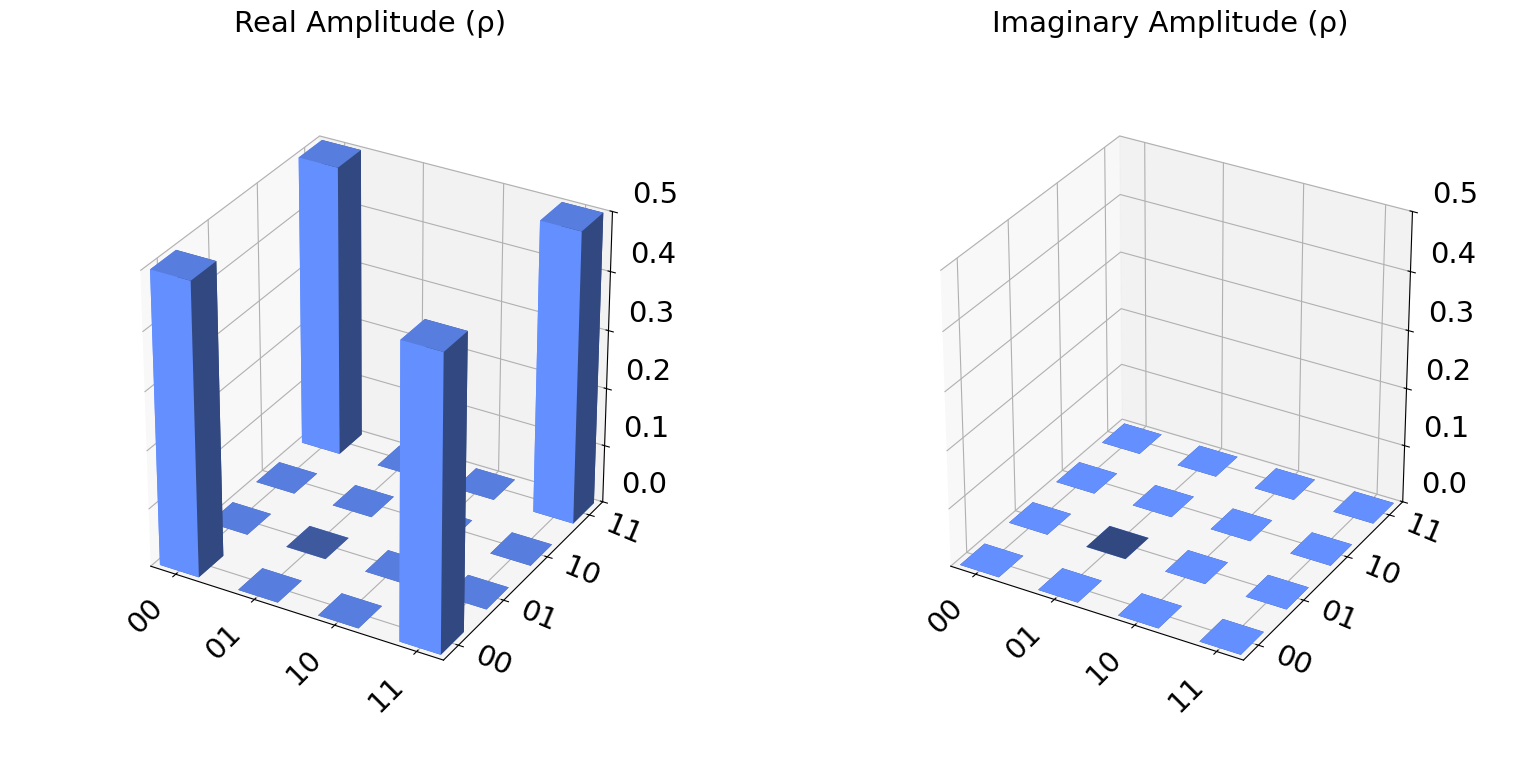

In [35]:
# Re-create phi-minus circuit
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.z(0)
# Control Z gate to flip phase back to positive
circuit.cz(0, 1)
new_phi_plus = Statevector(circuit)
plot_state_city(new_phi_plus)


# **Section 2: Building Gates (64 pts)**
This next section is dedicated to building custom gates by matrices, composition of gates, and quantum circuits.

## **Part 1: Arbitrary Unitary Gates (20 pts)**
Using `UnitaryGate`, you will create custom unitary gates from unitary matrices.

### An Example (4 pts)
Use the given matrix `arbitrary_unitary_matrix` and create a `UnitaryGate` with it. Then `evolve` the statevector $|0\rangle$ with it. Finally plot the resulting statevector using `plot_bloch_multivector`.

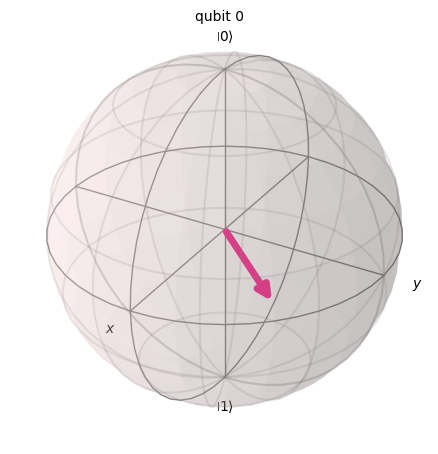

In [37]:
theta = 2*np.pi/5
arbitrary_unitary_gate = np.array([
    [np.cos(theta),np.sin(theta)],
    [-np.sin(theta),np.cos(theta)]
])
# YOUR CODE BELOW
new_gate = UnitaryGate(arbitrary_unitary_gate)
plot_bloch_multivector(new_gate)

### Creating an $X$ Gate (4 pts)
Design a numpy array that performs a $\pi$-rotation around the X-axis. Create a `UnitaryGate` with that matrix. Then `evolve` the statevector $|0\rangle$ with it. Finally plot the resulting statevector using `plot_bloch_multivector`.

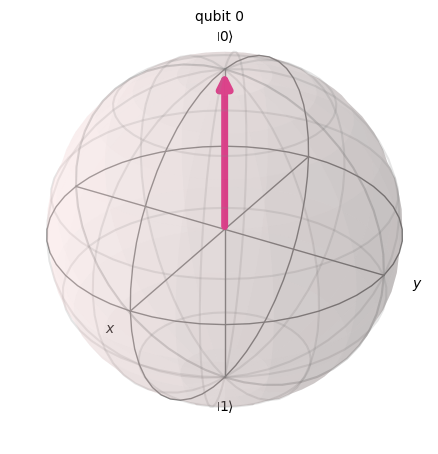

In [ ]:
# Manually create X gate array
x_gate_array = np.array([
    [0, 1],
    [1, 0]
])
x_gate = UnitaryGate(x_gate_array)
# Create a single bit statevector with default value |0>
circuit = QuantumCircuit(1)
sv = Statevector(circuit)
# Evolve statevector over X gate array and plot
sv = sv.evolve(x_gate_array)
plot_bloch_multivector(sv)

### Creating an $S$ Gate (4 pts)
Design a numpy array that performs a $\frac{\pi}{2}$-rotation around the Z-axis. Create a `UnitaryGate` with that matrix. Then `evolve` the statevector $|+\rangle$ with it. Finally plot the resulting statevector using `plot_bloch_multivector`.

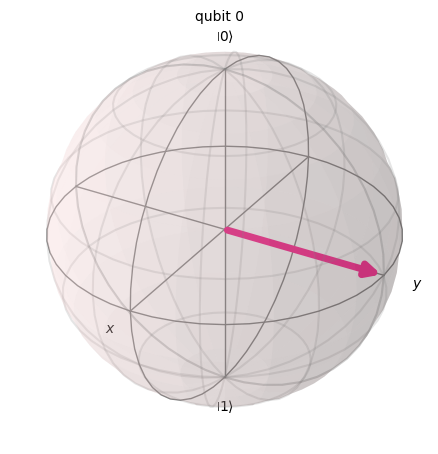

In [48]:
# Manually create S gate array
s_gate_array = np.array([
    [1, 0],
    [0, complex(0, 1)]
])
s_gate = UnitaryGate(s_gate_array)
# Create circuit with a single qubit (default state of |0>)
circuit = QuantumCircuit(1)
# Apply hadamard gate to qubit to flip it to |+>
circuit.h(0)
# Convert it to a statevector
sv = Statevector(circuit)
# Evolve statevector over S gate array and plot
sv = sv.evolve(s_gate_array)
plot_bloch_multivector(sv)


### Creating a CNOT Gate (8 pts)
Design a numpy array that performs a controlled-NOT gate. Create a `UnitaryGate` with that matrix. Then `evolve` the statevector $|01\rangle$ into $|11\rangle$ using that gate. Finally plot the resulting statevector using `plot_state_city`.

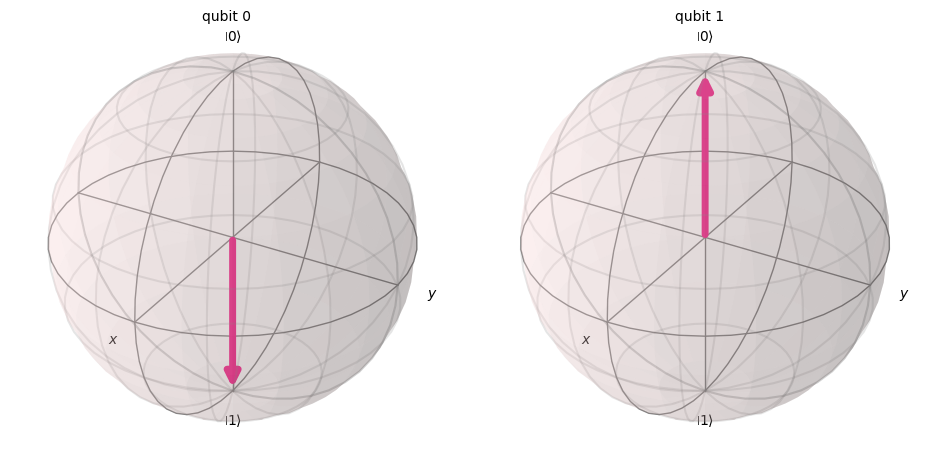

In [ ]:
# Manually create controlled-not gate array
c_not_gate_array = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]
])
c_not_gate = UnitaryGate(c_not_gate_array)
# Create circuit with a single qubit (default state of |0>)
circuit = QuantumCircuit(2)
# Apply x gate to qubit to flip bit 0 to a 1
circuit.x(0)
# Convert it to a statevector
sv = Statevector(circuit)
# Evolve statevector over controlled-not gate array and plot
sv = sv.evolve(c_not_gate, [1, 0])
plot_bloch_multivector(sv)


## **Part 2: Gate Composition (24 pts)**
Using numpy's `matmul` you will construct new quantum gates that perform a series of basis gates in one operation.

### Gate Composition Function (12 pts)
Finish the `compose_single_qubit_gates` python function such that it constructs a gate starting from identity through matrix multiplication (`np.matmul`) using the each gate's matrix (`to_matrix()`), then turns the final matrix into a `UnitaryGate`.

In [22]:
def compose_single_qubit_gates(*gates) -> UnitaryGate:
    # Notice on ordering:
    # Suppose *gates is XGate(), HGate()
    # then the composition is to apply a 
    # rotation equivalent to an XGate() rotation, 
    # then an HGate() rotation.

    # YOUR CODE BELOW
    

### The $T^\dagger$ Gate (4 pts)
Create a custom gate that is equivalent to the `TdgGate` by using only the `ZGate`, `SGate`, and `TGate`, then store it in the `gate_tdg` variable.

In [23]:

# YOUR CODE ABOVE

# This checks if the gates perform the same rotation.
# If no error, then your answer is correct.
assert np.allclose(gate_tdg.to_matrix(), TdgGate().to_matrix())

### The $X$ Gate (4 pts)
Create a custom gate that is equivalent to the `XGate` by using only the `ZGate` and `HGate`, then store it in the `gate_x` variable.

In [24]:

# YOUR CODE ABOVE

# This checks if the gates perform the same rotation.
# If no error, then your answer is correct.
assert np.allclose(gate_x.to_matrix(), XGate().to_matrix())

### The $S$ Gate (4 pts)
Create a custom gate that is equivalent to the `SGate` by using only the `HGate` and `SXGate`, then store it in the `gate_s` variable.

In [25]:

# YOUR CODE ABOVE

# This checks if the gates perform the same rotation.
# If no error, then your answer is correct.
assert np.allclose(gate_s.to_matrix(), SGate().to_matrix())

## **Part 3: Gates from Quantum Circuits (20 pts)**
You will create [`QuantumCircuit`](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit#quantumcircuit-class) objects that perform a selection of gates on some qubits, then turn that circuit into its own new gate operation to be used in other circuits.

### Building a Quantum Circuit (8 pts)
Create a `QuantumCircuit` with 2 qubits stored it in a variable `qc` that performs an $X$-gate on the first qubit and a $H$-gate on the second qubit. Then use its `draw` method in the matplotlib style.

In [ ]:
# YOUR CODE BELOW


### Converting the Circuit to a Gate (4 pts)
Using the quantum circuit `qc` from the previous cell, convert it into a quantum gate `gate_qc` with a `label` $HX$ using its [`to_gate`](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit#to_gate) method.

In [27]:
# YOUR CODE BELOW


### Using the Circuit-Gate (4 pts)
Create a new 2-qubit quantum circuit `qc_gate_applied` and using its `append` method, add the gate `gate_qc` to it. Draw the new circuit in matplotlib style.

In [ ]:
# YOUR CODE BELOW


### Checking Equivalence (2 pts)
Check if your circuits `qc` and `qc_gate_applied` are equivalent.

In [ ]:
# YOUR CODE BELOW


### Establishing Equivalence with Decomposition (2 pts)
You should see despite `qc` and `qc_gate_applied` performing the same basis gates on the same qubits, their construction differs which is why they are not equivalent in Qiskit, but there's a way to check for basis gate equivalence.
`decompose` the `HX` gate in `qc_gate_applied` to yield a new quantum circuit and compare that to `qc`. 

In [ ]:
# YOUR CODE BELOW


# **Section 3: The Swap Test (50 pts)**
**This section is intended for graduate students, but may be completed by undergraduate students for extra credit**

<img alt="Image" src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fimages.squarespace-cdn.com%2Fcontent%2Fv1%2F5d52f7bd9d7b3e0001819015%2F93ff12b9-3837-41b9-89ad-fa6932611432%2Fswaptest.png&f=1&nofb=1&ipt=244d6027f9c948a85a13cca9d30de9d1daa1a6a55698b29f11cec4aab2ded550&ipo=images">


You will create a [Swap Test](https://en.wikipedia.org/wiki/Swap_test) circuit and turn it into a gate to be used to compare quantum states in a new circuit.

## **Part 1: Building a Swap Gate (10 pts)**
Design a 4x4 numpy array that swaps the quantum states of two qubits, then create a `UnitaryGate` with a `label` *Swap* from the matrix and store it in a variable `gate_swap`. Do not use `SwapGate`.

In [31]:

# YOUR CODE ABOVE

# Ensures your swap gate performs the same as the SwapGate
assert np.allclose(SwapGate().to_matrix(), gate_swap.to_matrix())

## **Part 2: Building the Swap Test Circuit (10 pts)**
Create a 3-qubit quantum circuit stored in `qc_swap_test`. Then apply a hadamard gate on the first qubit, then apply your `gate_swap` targeting the second and third qubits controlled by the first. Finally, apply another hadamard gate on the first qubit, but *do not measure it*. Draw the circuit using the matplotlib style.

In [ ]:
# YOUR CODE BELOW


## **Part 3: Turning the Swap Test into a Gate (5 pts)**
Convert the Swap Test circuit `qc_swap_test` into a quantum gate `gate_swap_test` with a `label` *Swap Test*. Apply it to a new 3-qubit 1-classical bit quantum circuit `qc_swap_draw`. Apply a measurement to the first qubit, then draw this circuit with matplotlib style.

In [ ]:
# YOUR CODE BELOW


## **Part 4: Swap Test Experiments (25 pts)**
You will perform the swap test on a variety of single-qubit quantum state pairs to understand how the similarity measure works.

### Circuit Simulation Function (10 pts)
Finish the code for the `swap_test_expectation_value` Python function. Using the `StatevectorEstimator`, run a primitive unified block (PUB) containing `circuit` and an observable equivalent to measuring the first qubit in the computational basis using `Pauli`. Use the estimator's `run` on the pub enclosed in a list. Then fetch the `result` and grab its `data.evs` to return a similarity measure value.

In [34]:
def swap_test_expectation_value(circuit: QuantumCircuit) -> float:
    # YOUR CODE BELOW


### Swap Test on $|0\rangle$ and $|1\rangle$ (3 pts)
Create a quantum circuit `qc_swap_test_10` with 3 qubits. Initialize the second qubit in $|0\rangle$ and the third qubit in $|1\rangle$. Apply the swap test gate `gate_swap_test` to the appropriate qubits. Print the Swap Test result using `swap_test_expectation_value`. Draw the circuit in matplotlib style.

In [ ]:
# YOUR CODE BELOW


### Swap Test on $|0\rangle$ and $|+\rangle$ (3 pts)
Create a quantum circuit `qc_swap_test_plus0` with 3 qubits. Initialize the second qubit in $|0\rangle$ and the third qubit in $|+\rangle$. Apply the swap test gate `gate_swap_test` to the appropriate qubits. Print the Swap Test result using `swap_test_expectation_value`. Draw the circuit in matplotlib style.

In [ ]:
# YOUR CODE BELOW


### Swap Test on $|-\rangle$ and $|-\rangle$ (3 pts)
Create a quantum circuit `qc_swap_test_minusminus` with 3 qubits. Initialize the second qubit in $|-\rangle$ and the third qubit in $|-\rangle$. Apply the swap test gate `gate_swap_test` to the appropriate qubits. Print the Swap Test result using `swap_test_expectation_value`. Draw the circuit in matplotlib style.

In [ ]:
# YOUR CODE BELOW


### Swap Test on $|-\rangle$ and $|+\rangle$ (3 pts)
Create a quantum circuit `qc_swap_test_plusminus` with 3 qubits. Initialize the second qubit in $|-\rangle$ and the third qubit in $|+\rangle$. Apply the swap test gate `gate_swap_test` to the appropriate qubits. Print the Swap Test result using `swap_test_expectation_value`. Draw the circuit in matplotlib style.

In [ ]:
# YOUR CODE BELOW


### Swap Test on Near-Identical States (3 pts)
Create a quantum circuit `qc_swap_test_plusminus` with 3 qubits. Initialize the second and third qubits in $|1\rangle$, but apply a $R_x(\frac{\pi}{8})$-gate to the third qubit. Apply the swap test gate `gate_swap_test` to the appropriate qubits. Print the Swap Test result using `swap_test_expectation_value`. Draw the circuit in matplotlib style.

In [ ]:
# YOUR CODE BELOW


# Submitting Your Work
If you have completed this programming homework exercise, well done! <br><br>
To submit your work, please follow these steps.
1. Convert this notebook to HTML by opening a terminal, and running<br><br>
`jupyter nbconvert --to html FILEPATH_TO_NOTEBOOK` (replacing `FILEPATH_TO_NOTEBOOK`)<br><br>
2. Open your HTML file in a browser
3. Right-click in the browser and click print
4. Change print settings to save as a pdf, set the margin to none, and downscale (if necessary, but don't make it too small)
5. Upload your PDF file to the Pilot dropbox